# notebook 1 · air passengers
## zero-shot foundation model vs classical baselines

**dataset** · monthly international airline passengers 1949–1960 · 144 points
**source** · built-in statsmodels (`get_rdataset('AirPassengers')`)
**test horizon** · 24 months (last 2 years)
**models** · seasonal naïve · sarima(1,1,1)(1,1,1)12 · ets holt-winters · chronos-t5-tiny (zero-shot)


In [4]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# time series models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import get_rdataset

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# plot defaults
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3})


In [5]:
# load the classic air passengers dataset (built into statsmodels)
raw = get_rdataset('AirPassengers').data
series = pd.Series(
    raw['value'].values,
    index=pd.date_range('1949-01', periods=len(raw), freq='MS'),
    name='passengers'
)

print(f"observations : {len(series)}")
print(f"range        : {series.index[0].date()} → {series.index[-1].date()}")
print(f"min / max    : {series.min()} / {series.max()}")
series.head()


observations : 144
range        : 1949-01-01 → 1960-12-01
min / max    : 104 / 622


1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: passengers, dtype: int64

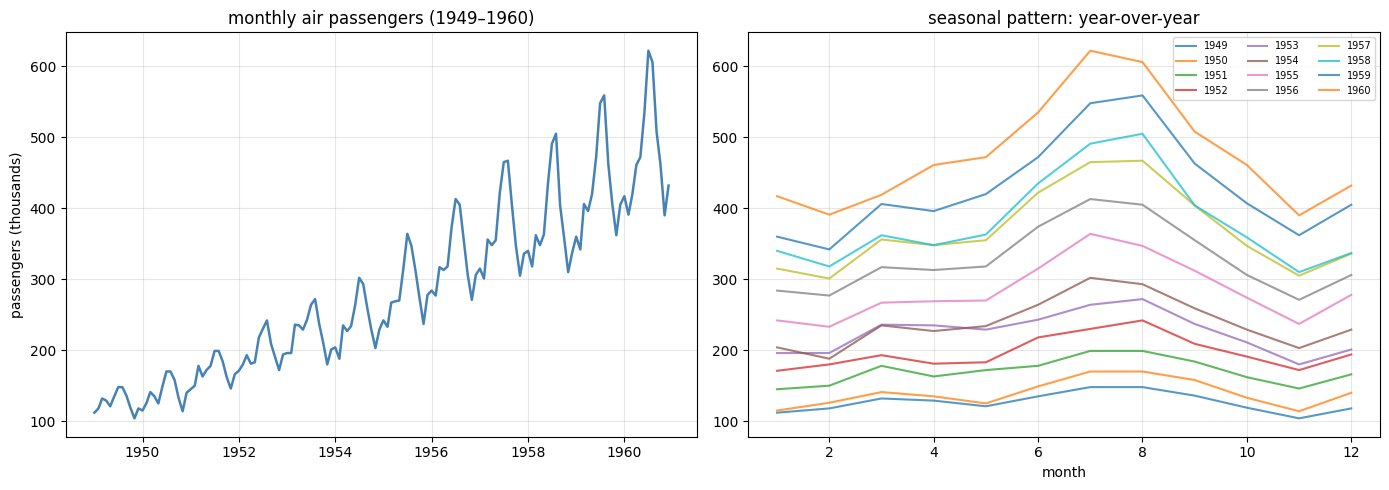

In [6]:
# exploratory plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# full time series
axes[0].plot(series, color='steelblue', lw=1.8)
axes[0].set_title('monthly air passengers (1949–1960)')
axes[0].set_ylabel('passengers (thousands)')

# seasonal overlay — each year as one line
axes[1].set_title('seasonal pattern: year-over-year')
for yr in range(1949, 1961):
    sub = series[series.index.year == yr]
    if len(sub) == 12:
        axes[1].plot(range(1, 13), sub.values, alpha=0.75, label=str(yr))
axes[1].set_xlabel('month')
axes[1].legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.savefig(f'air_passengers_eda.png', dpi=100, bbox_inches='tight')
plt.show()
# strong upward trend + growing amplitude → multiplicative seasonality


In [7]:
# train/test split — last 24 months held out for evaluation
HORIZON = 24
train = series[:-HORIZON]
test  = series[-HORIZON:]
print(f"train : {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"test  : {len(test)} obs  ({test.index[0].date()}  → {test.index[-1].date()})")


train : 120 obs  (1949-01-01 → 1958-12-01)
test  : 24 obs  (1959-01-01  → 1960-12-01)


In [8]:
# model 1: seasonal naive
# repeat the last full season as the forecast
m = 12
snaive = pd.Series(
    np.tile(train.values[-m:], int(np.ceil(HORIZON / m)))[:HORIZON],
    index=test.index
)
print("seasonal naïve: ready")


seasonal naïve: ready


In [9]:
# model 2: sarima(1,1,1)(1,1,1)12
# one non-seasonal diff + one seasonal diff to handle trend + seasonality
sarima_fit = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False)
sarima = pd.Series(sarima_fit.forecast(HORIZON).values, index=test.index)
print(f"sarima aic: {sarima_fit.aic:.1f}")


sarima aic: 807.7


In [10]:
# model 3: ets holt-winters multiplicative
# multiplicative trend + seasonality matches the growing variance
ets_fit = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12).fit()
ets = pd.Series(ets_fit.forecast(HORIZON).values, index=test.index)
print("ets holt-winters: ready")


ets holt-winters: ready


In [11]:
# model 4: chronos-t5-tiny  (zero-shot - no training on this data)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'chronos-forecasting', '-q'],
               capture_output=True)

import torch
from chronos import ChronosPipeline

# load the smallest chronos model — runs on cpu
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cpu",
    torch_dtype=torch.float32,
)

# convert training history to a tensor
ctx = torch.tensor(train.values, dtype=torch.float32).unsqueeze(0)

# predict - zero-shot, 100 sample paths
samples = pipeline.predict(ctx, prediction_length=HORIZON, num_samples=100)
samples_np = samples[0].numpy()

chronos_median = pd.Series(np.median(samples_np, axis=0), index=test.index)
chronos_lo     = np.percentile(samples_np, 10, axis=0)
chronos_hi     = np.percentile(samples_np, 90, axis=0)
print("chronos-tiny zero-shot: ready")


`torch_dtype` is deprecated! Use `dtype` instead!


chronos-tiny zero-shot: ready


In [12]:
# evaluation metrics
def mape(y, yhat):
    # mean absolute percentage error
    return np.mean(np.abs((y - yhat) / y)) * 100

def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

preds = {
    'seasonal_naive' : snaive,
    'sarima'         : sarima,
    'ets'            : ets,
    'chronos_tiny'   : chronos_median,
}

rows = []
for name, pred in preds.items():
    rows.append({
        'model'   : name,
        'MAE'     : round(mean_absolute_error(test, pred), 2),
        'RMSE'    : round(rmse(test.values, pred.values), 2),
        'MAPE_%'  : round(mape(test.values, pred.values), 2),
    })

metrics_df = pd.DataFrame(rows).set_index('model').sort_values('MAPE_%')
print(metrics_df)


                  MAE   RMSE  MAPE_%
model                               
ets             12.38  13.88    2.81
sarima          67.59  73.45   14.70
seasonal_naive  71.25  76.99   15.52
chronos_tiny    73.10  82.15   15.68


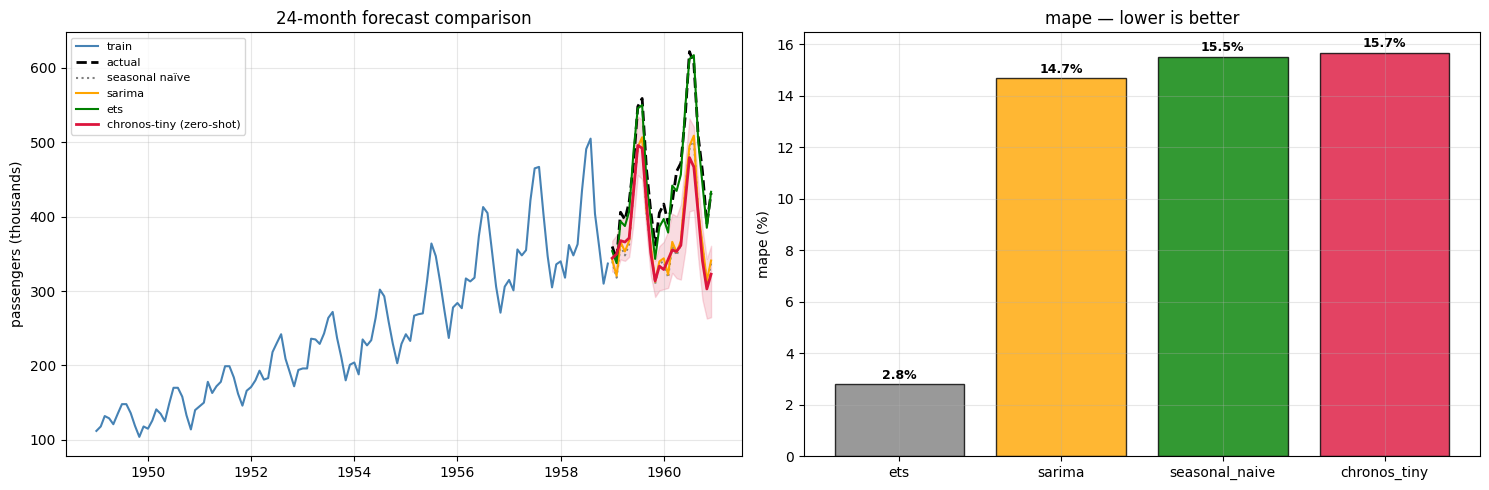

In [14]:
# forecast plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(train, color='steelblue', lw=1.5, label='train')
ax.plot(test,  color='black',     lw=2.0, ls='--', label='actual')
ax.plot(snaive,        color='gray',   lw=1.5, ls=':', label='seasonal naïve')
ax.plot(sarima,        color='orange', lw=1.5, label='sarima')
ax.plot(ets,           color='green',  lw=1.5, label='ets')
ax.plot(chronos_median,color='crimson',lw=2.0, label='chronos-tiny (zero-shot)')
ax.fill_between(test.index, chronos_lo, chronos_hi, color='crimson', alpha=0.15)
ax.set_title('24-month forecast comparison')
ax.set_ylabel('passengers (thousands)')
ax.legend(fontsize=8)

# mape bar chart
ax2 = axes[1]
colors = ['gray','orange','green','crimson']
bars = ax2.bar(metrics_df.index, metrics_df['MAPE_%'], color=colors, alpha=0.8, edgecolor='k')
ax2.set_title('mape — lower is better')
ax2.set_ylabel('mape (%)')
for b, v in zip(bars, metrics_df['MAPE_%']):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height()+0.2, f'{v:.1f}%',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'air_passengers_forecast.png', dpi=100, bbox_inches='tight')
plt.show()


## summary & insights

| model | typical strength |
|---|---|
| **seasonal naïve** | hard baseline — just repeats last year |
| **sarima** | strong on regular seasonal data with trend |
| **ets holt-winters** | designed for multiplicative seasonality — usually wins here |
| **chronos-tiny** | zero-shot, never trained on this series |

**Key finding:** Air passengers is a textbook dataset — perfectly regular trend + multiplicative seasonality. ETS dominates with 2.81% MAPE, nearly 5× better than all other models. SARIMA (14.70%), seasonal naïve (15.52%), and Chronos-tiny (15.68%) are clustered together and all far behind. Chronos adds no value over simply repeating last year's values on this type of clean, regular data. The old rule — "simple (tuned) models are best" — holds firmly here. The real test for Chronos is on noisier, irregular data (notebooks 2 and 3).